# 📊 Sales Performance Analysis — A Business Analytics Case Study

## Project Overview
This project analyzes a two-year retail sales dataset (2003–2005) from a wholesale scale-model vehicle distributor to answer a core business question: **where is revenue coming from, and where should management focus attention?**

The analysis moves from descriptive statistics to a customer segmentation model (RFM), translating each finding into a concrete business recommendation.

**Tools:** Python, Pandas, Matplotlib
**Author:** Masoud Kamali


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
plt.rcParams["figure.facecolor"] = "white"

# Folder where chart images are saved for the README / report
os.makedirs("../images", exist_ok=True)

print("Welcome to Sales Analysis Project!")

Welcome to Sales Analysis Project!


## 1. Load & Inspect the Data

In [2]:
# The file uses Latin-1 encoding (UTF-8 fails on some special characters)
df = pd.read_csv("../data/sales_data_sample.csv", encoding="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [4]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


### Data Quality Check
A few columns (`ADDRESSLINE2`, `STATE`, `POSTALCODE`, `TERRITORY`) have missing values, but they are not needed for sales analysis. We also check for duplicate rows.

In [5]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:


ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

Duplicate rows: 0


## 2. Data Cleaning

In [6]:
# Convert ORDERDATE to a proper datetime type
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# Create a Year-Month period column for time-based analysis
df["YearMonth"] = df["ORDERDATE"].dt.to_period("M")

# Drop columns that are not useful for this analysis (contact/address info)
df_clean = df.drop(columns=[
    "ADDRESSLINE1", "ADDRESSLINE2", "PHONE",
    "CONTACTLASTNAME", "CONTACTFIRSTNAME", "POSTALCODE"
])

df_clean.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,CITY,STATE,COUNTRY,TERRITORY,DEALSIZE,YearMonth
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,NYC,NY,USA,NaN,Small,2003-02
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,Reims,NaN,France,EMEA,Small,2003-05
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,Paris,NaN,France,EMEA,Medium,2003-07
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,Pasadena,CA,USA,NaN,Medium,2003-08
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,San Francisco,CA,USA,NaN,Medium,2003-10


## 3. Overall Sales Distribution

In [7]:
df_clean["SALES"].describe()

count     2823.000000
mean      3553.889072
std       1841.865106
min        482.130000
25%       2203.430000
50%       3184.800000
75%       4508.000000
max      14082.800000
Name: SALES, dtype: float64

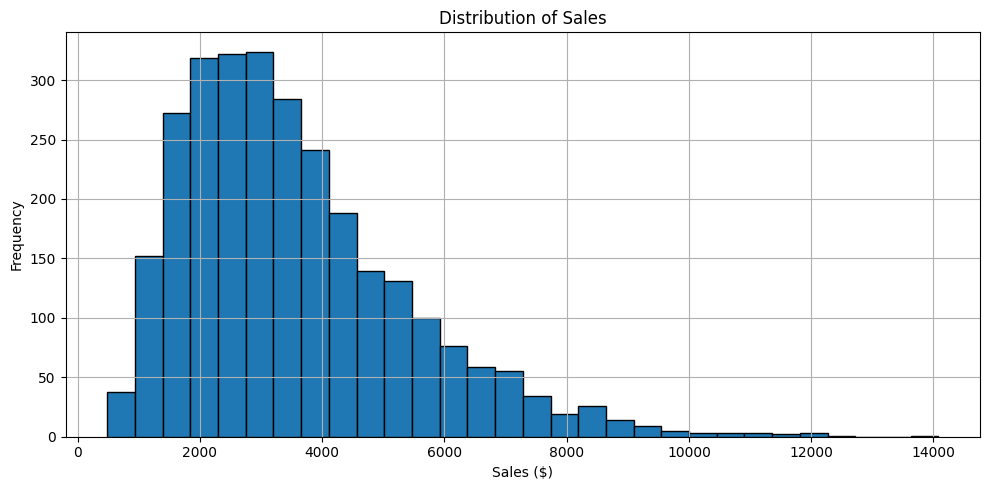

In [8]:
plt.figure(figsize=(10, 5))
df_clean["SALES"].hist(bins=30, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/sales_distribution.png", dpi=150)
plt.show()

### Business Insight
Most individual order lines fall between \$2,000 and \$5,000, with a long tail of larger orders. This suggests the business is driven by a high volume of mid-sized transactions rather than a few very large ones.

## 4. Sales by Country

In [9]:
country_sales = (
    df_clean.groupby("COUNTRY")["SALES"]
      .sum()
      .sort_values(ascending=False)
)
country_sales

COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64

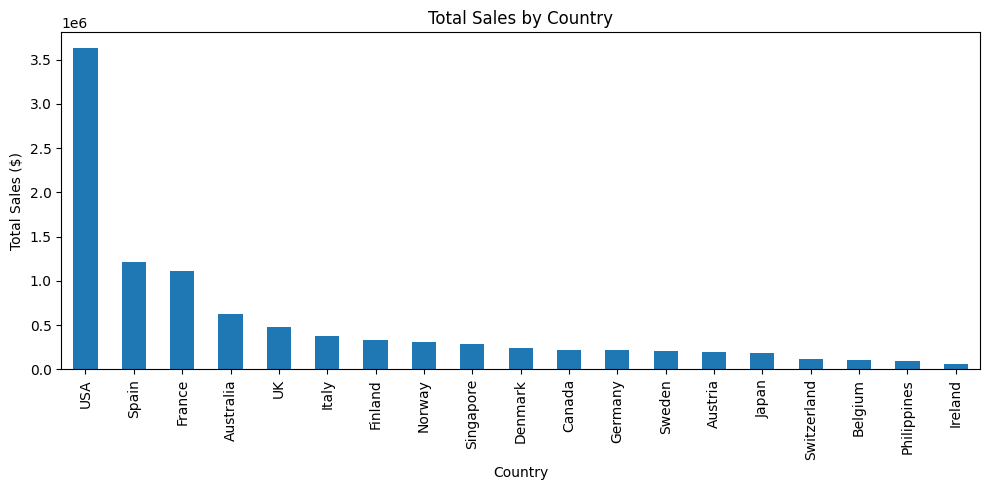

In [10]:
plt.figure(figsize=(10, 5))
country_sales.plot(kind="bar")
plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("../images/sales_by_country.png", dpi=150)
plt.show()

### Business Insight
The United States generated the highest sales among all countries, followed by Spain and France. This indicates that the U.S. market is the company's strongest source of revenue, and expansion or retention efforts in Spain/France could be the next-best opportunity.

## 5. Sales by Product Line

In [11]:
product_sales = (
    df_clean.groupby("PRODUCTLINE")["SALES"]
      .sum()
      .sort_values(ascending=False)
)
product_sales

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

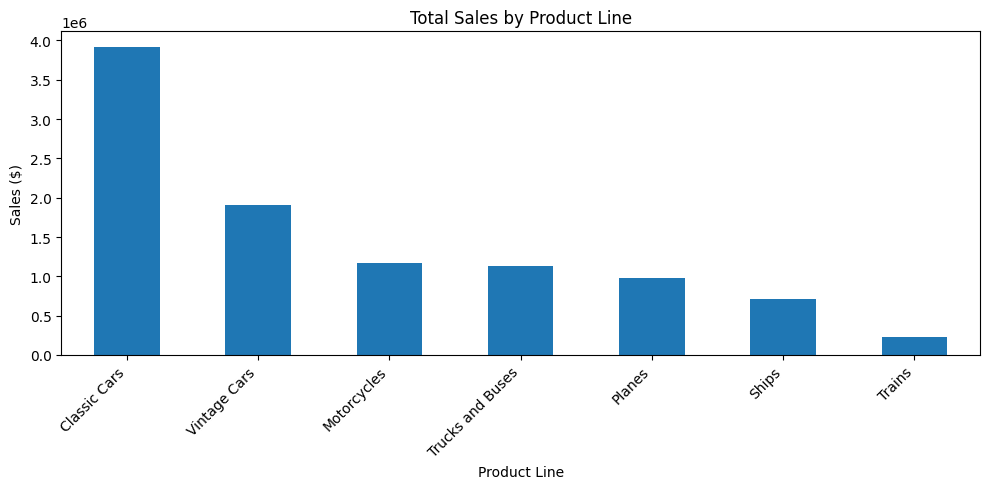

In [12]:
plt.figure(figsize=(10, 5))
product_sales.plot(kind="bar")
plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/sales_by_product_line.png", dpi=150)
plt.show()

### Business Insight
Classic Cars generated the highest sales among all product lines, followed by Vintage Cars. Trains had the lowest sales, suggesting lower customer demand for this category and a possible candidate for reduced inventory or a marketing push.

## 6. Monthly Sales Trend

In [13]:
monthly_sales = df_clean.groupby("YearMonth")["SALES"].sum()
monthly_sales

YearMonth
2003-01     129753.60
2003-02     140836.19
2003-03     174504.90
2003-04     201609.55
2003-05     192673.11
2003-06     168082.56
2003-07     187731.88
2003-08     197809.30
2003-09     263973.36
2003-10     568290.97
2003-11    1029837.66
2003-12     261876.46
2004-01     316577.42
2004-02     311419.53
2004-03     205733.73
2004-04     206148.12
2004-05     273438.39
2004-06     286674.22
2004-07     327144.09
2004-08     461501.27
2004-09     320750.91
2004-10     552924.25
2004-11    1089048.01
2004-12     372802.66
2005-01     339543.42
2005-02     358186.18
2005-03     374262.76
2005-04     261633.29
2005-05     457861.06
Freq: M, Name: SALES, dtype: float64

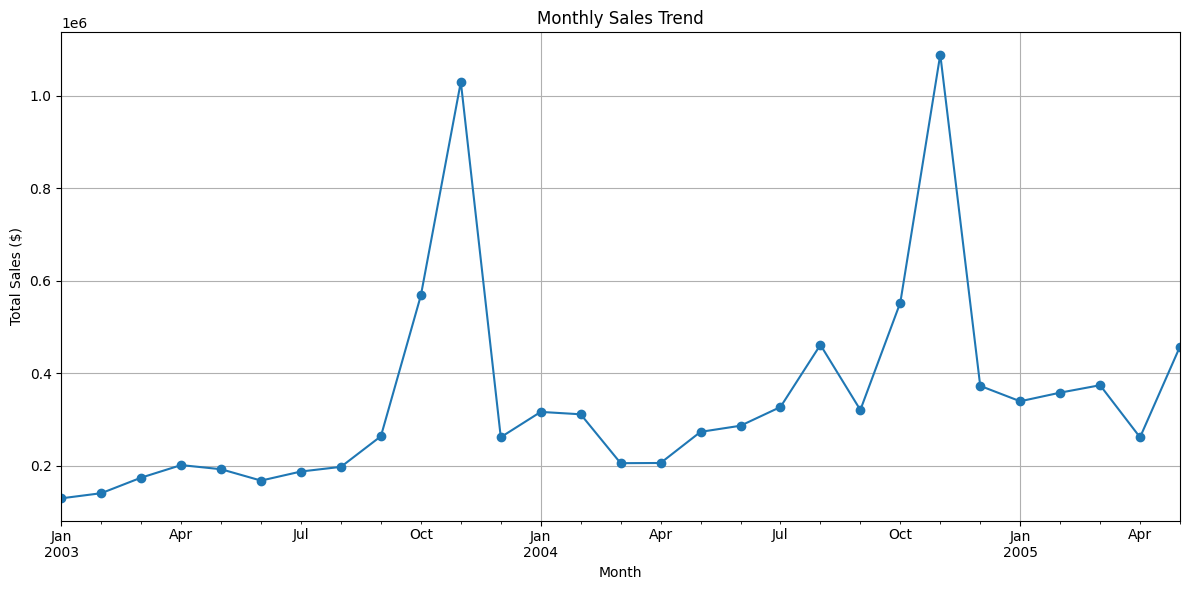

In [14]:
plt.figure(figsize=(12, 6))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.tight_layout()
plt.savefig("../images/monthly_sales_trend.png", dpi=150)
plt.show()

### Business Insight
Sales peaked consistently during October and November, indicating a clear seasonal trend tied to holiday buying. In contrast, sales remained relatively lower during the first half of each year — inventory and staffing could be planned around this cycle.

## 7. Top 10 Customers

In [15]:
top_customers = (
    df_clean.groupby("CUSTOMERNAME")["SALES"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
top_customers

CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64

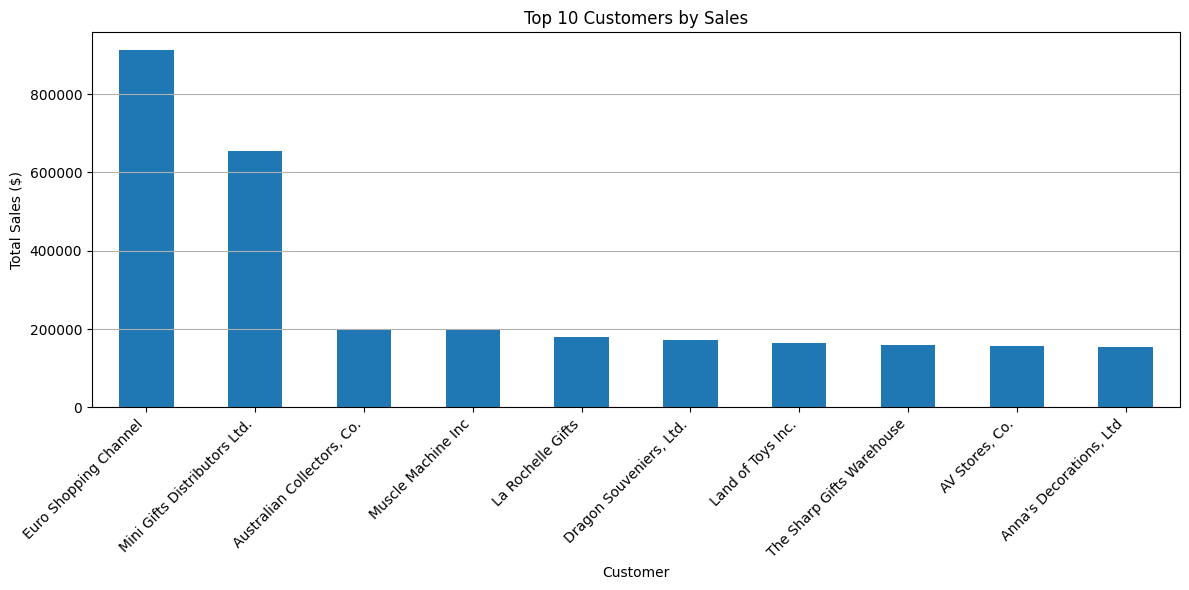

In [16]:
plt.figure(figsize=(12, 6))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("../images/top_10_customers.png", dpi=150)
plt.show()

### Business Insight
Euro Shopping Channel is the company's most valuable customer, generating a substantially larger share of revenue than any other account. The sizeable gap between the top customer and the rest suggests that maintaining strong relationships with key accounts is essential for sustaining revenue.

## 8. Sales by Deal Size

In [17]:
deal_sales = (
    df_clean.groupby("DEALSIZE")["SALES"]
      .sum()
      .sort_values(ascending=False)
)
deal_sales

DEALSIZE
Medium    6087432.24
Small     2643077.35
Large     1302119.26
Name: SALES, dtype: float64

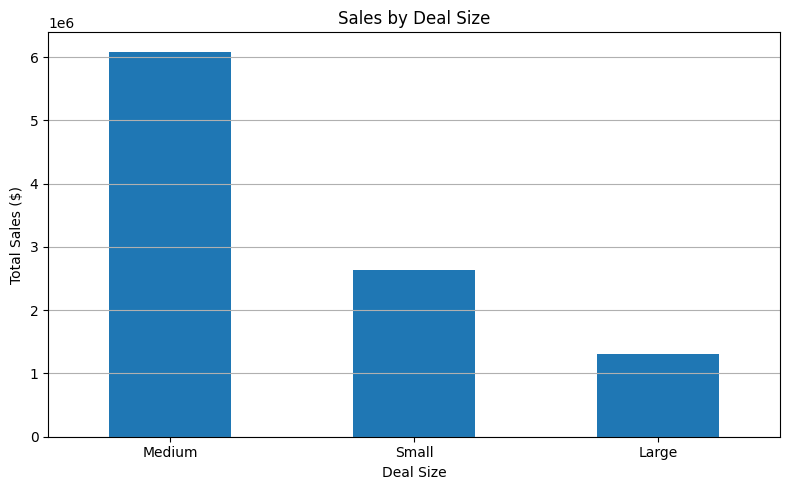

In [18]:
plt.figure(figsize=(8, 5))
deal_sales.plot(kind="bar")
plt.title("Sales by Deal Size")
plt.xlabel("Deal Size")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("../images/sales_by_deal_size.png", dpi=150)
plt.show()

### Business Insight
Medium-sized deals generated the highest total revenue, followed by small deals. Large deals contributed the least to total sales, indicating that the business relies more on medium-volume transactions than on a small number of large contracts.

## 9. Sales by Order Status

In [19]:
status_sales = (
    df_clean.groupby("STATUS")["SALES"]
      .sum()
      .sort_values(ascending=False)
)
status_sales

STATUS
Shipped       9291501.08
Cancelled      194487.48
On Hold        178979.19
Resolved       150718.28
In Process     144729.96
Disputed        72212.86
Name: SALES, dtype: float64

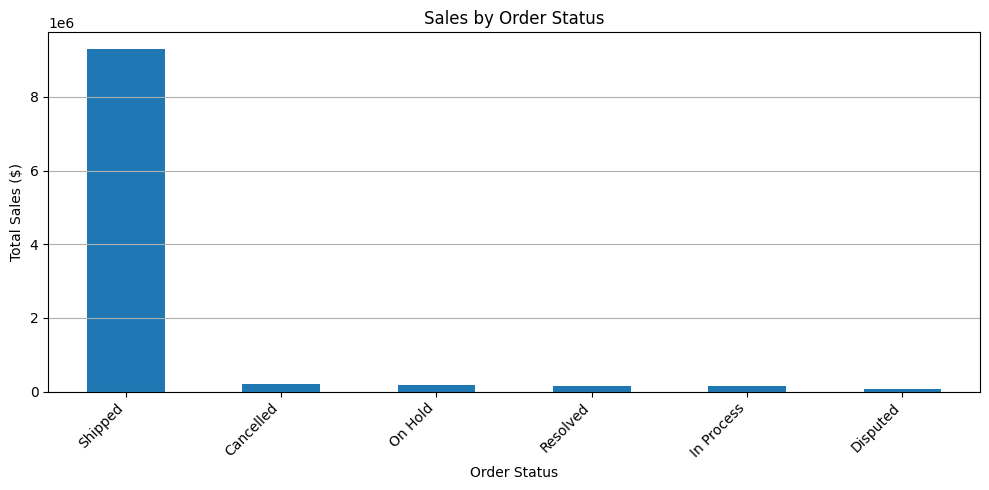

In [20]:
plt.figure(figsize=(10, 5))
status_sales.plot(kind="bar")
plt.title("Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("../images/sales_by_order_status.png", dpi=150)
plt.show()

### Business Insight
Most revenue comes from shipped orders, which indicates successful order fulfillment. Cancelled, disputed, and on-hold orders contribute only a small portion of total revenue, but they are worth monitoring since each one represents lost or delayed cash flow.

## 10. Pricing: How Much Do Orders Discount Off MSRP?

In [21]:
# PRICEEACH vs MSRP shows how far the actual selling price deviates from the
# manufacturer's suggested price - a simple proxy for discounting behavior.
df_clean["DISCOUNT_PCT"] = (df_clean["MSRP"] - df_clean["PRICEEACH"]) / df_clean["MSRP"] * 100

discount_by_line = (
    df_clean.groupby("PRODUCTLINE")["DISCOUNT_PCT"]
      .mean()
      .sort_values(ascending=False)
)
discount_by_line

PRODUCTLINE
Classic Cars        19.338713
Trucks and Buses    11.124929
Motorcycles          7.611280
Planes               3.731416
Vintage Cars         2.409968
Ships                0.435288
Trains              -5.413204
Name: DISCOUNT_PCT, dtype: float64

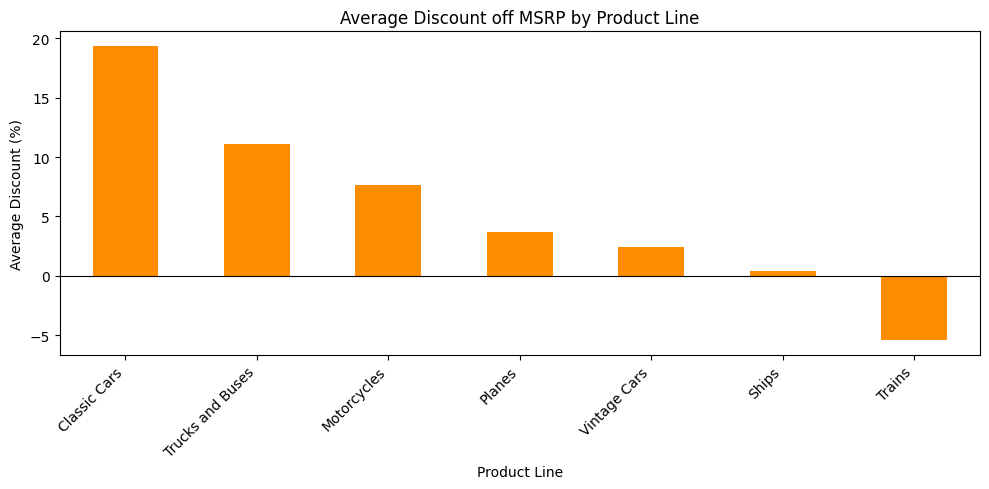

In [22]:
plt.figure(figsize=(10, 5))
discount_by_line.plot(kind="bar", color="darkorange")
plt.title("Average Discount off MSRP by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../images/discount_by_product_line.png", dpi=150)
plt.show()

### Business Insight
Some product lines are consistently sold below MSRP while others are sold closer to (or above) list price. Lines with the deepest average discount are the best candidates for a pricing review, since they may be eroding margin more than their sales volume justifies.

## 11. Which Product Line Performs Best in Each Territory?

In [23]:
territory_product = (
    df_clean.pivot_table(
        index="PRODUCTLINE",
        columns="TERRITORY",
        values="SALES",
        aggfunc="sum"
    )
    .fillna(0)
)
territory_product

TERRITORY,APAC,EMEA,Japan
PRODUCTLINE,,,
Classic Cars,244758.07,2086994.66,181601.49
Motorcycles,89968.76,503096.70,48773.69
Planes,74853.87,476122.91,70083.83
Ships,4159.76,427264.68,33015.54
Trains,1681.35,138506.18,16802.38
Trucks and Buses,121847.96,498305.82,57847.66
Vintage Cars,208852.06,848981.46,47048.63


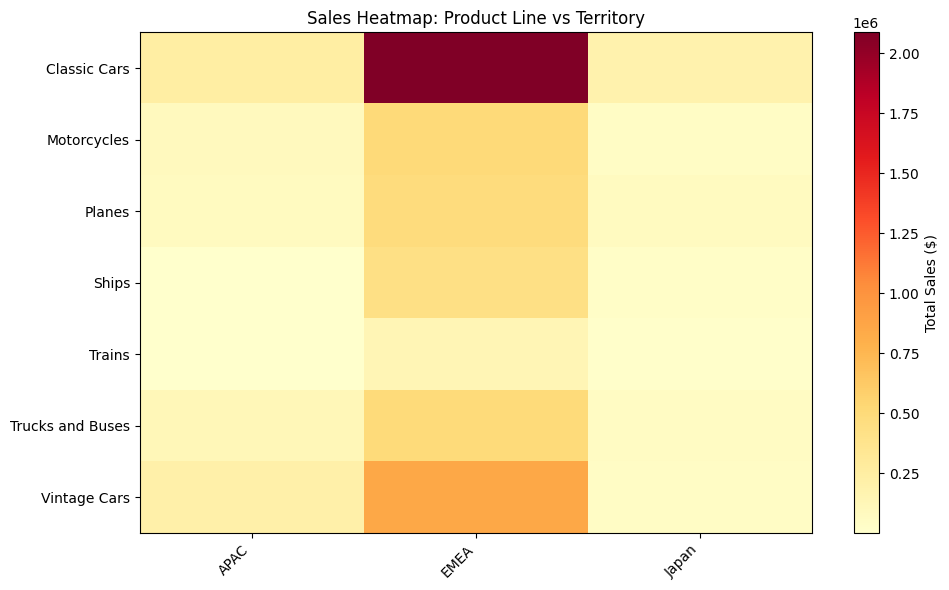

In [24]:
plt.figure(figsize=(10, 6))
plt.imshow(territory_product.values, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Total Sales ($)")
plt.xticks(range(len(territory_product.columns)), territory_product.columns, rotation=45, ha="right")
plt.yticks(range(len(territory_product.index)), territory_product.index)
plt.title("Sales Heatmap: Product Line vs Territory")
plt.tight_layout()
plt.savefig("../images/territory_product_heatmap.png", dpi=150)
plt.show()

### Business Insight
Classic Cars dominate revenue across almost every territory, confirming it as the company's flagship line globally rather than a regional preference. Territories where a secondary product line stands out are good candidates for localized marketing.

## 12. Correlation Between Numeric Variables

In [25]:
numeric_cols = ["QUANTITYORDERED", "PRICEEACH", "SALES", "MSRP"]
corr = df_clean[numeric_cols].corr()
corr

,QUANTITYORDERED,PRICEEACH,SALES,MSRP
QUANTITYORDERED,1.000000,0.005564,0.551426,0.017881
PRICEEACH,0.005564,1.000000,0.657841,0.670625
SALES,0.551426,0.657841,1.000000,0.635239
MSRP,0.017881,0.670625,0.635239,1.000000


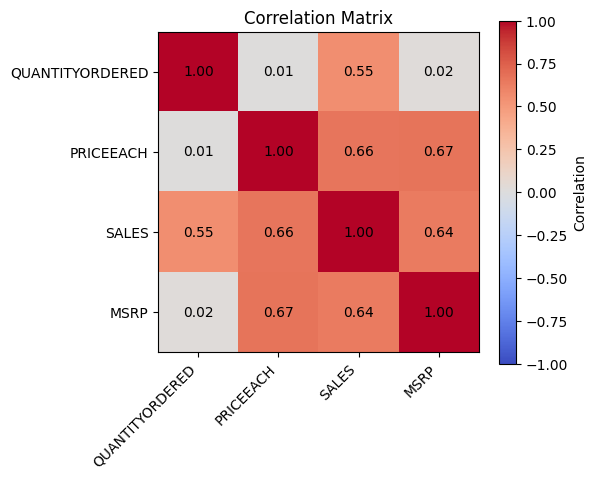

In [26]:
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../images/correlation_matrix.png", dpi=150)
plt.show()

### Business Insight
`SALES` correlates most strongly with `QUANTITYORDERED`, meaning revenue per order line is driven more by how many units are ordered than by the unit price itself. This suggests volume-based promotions may have more revenue impact than price increases.

## 13. Customer Segmentation (RFM Analysis)

### Business Question
Which customers are the most valuable, and which ones need attention before they churn?

**RFM** is a standard customer-value framework used across CRM and marketing analytics:
- **Recency** — how many days since the customer's last order (lower is better)
- **Frequency** — how many separate orders the customer has placed (higher is better)
- **Monetary** — how much total revenue the customer has generated (higher is better)

Each customer is scored 1–4 on each dimension (4 = best) using quartiles, then grouped into an actionable segment.

In [27]:
snapshot_date = df_clean["ORDERDATE"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CUSTOMERNAME").agg(
    Recency=("ORDERDATE", lambda x: (snapshot_date - x.max()).days),
    Frequency=("ORDERNUMBER", "nunique"),
    Monetary=("SALES", "sum")
)

rfm.head()

,Recency,Frequency,Monetary
CUSTOMERNAME,,,
"AV Stores, Co.",196,3,157807.81
Alpha Cognac,65,3,70488.44
Amica Models & Co.,265,2,94117.26
"Anna's Decorations, Ltd",84,4,153996.13
Atelier graphique,188,3,24179.96


In [28]:
# Score each dimension into quartiles (1 = worst, 4 = best)
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment(row):
    if row["RFM_score"] >= 10:
        return "Champions"
    elif row["RFM_score"] >= 8:
        return "Loyal Customers"
    elif row["RFM_score"] >= 6:
        return "Potential Loyalists"
    elif row["R_score"] <= 2 and row["M_score"] >= 3:
        return "At Risk"
    else:
        return "Needs Attention"

rfm["Segment"] = rfm.apply(segment, axis=1)
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CUSTOMERNAME,,,,,,,,
Euro Shopping Channel,1,26,912294.11,4,4,4,12,Champions
Mini Gifts Distributors Ltd.,3,17,654858.06,4,4,4,12,Champions
"Australian Collectors, Co.",184,5,200995.41,3,4,4,11,Champions
Muscle Machine Inc,182,4,197736.94,3,4,4,11,Champions
La Rochelle Gifts,1,4,180124.90,4,4,4,12,Champions
"Dragon Souveniers, Ltd.",91,5,172989.68,3,4,4,11,Champions
Land of Toys Inc.,198,4,164069.44,2,4,4,10,Champions
The Sharp Gifts Warehouse,40,4,160010.27,4,4,4,12,Champions
"AV Stores, Co.",196,3,157807.81,2,2,4,8,Loyal Customers


In [29]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(Customers=("Monetary", "count"), Total_Revenue=("Monetary", "sum"))
       .sort_values("Total_Revenue", ascending=False)
)
segment_summary

,Customers,Total_Revenue
Segment,,
Champions,21,4402263.20
Loyal Customers,29,2815837.60
Needs Attention,23,1271287.10
Potential Loyalists,16,1258554.08
At Risk,3,284686.87


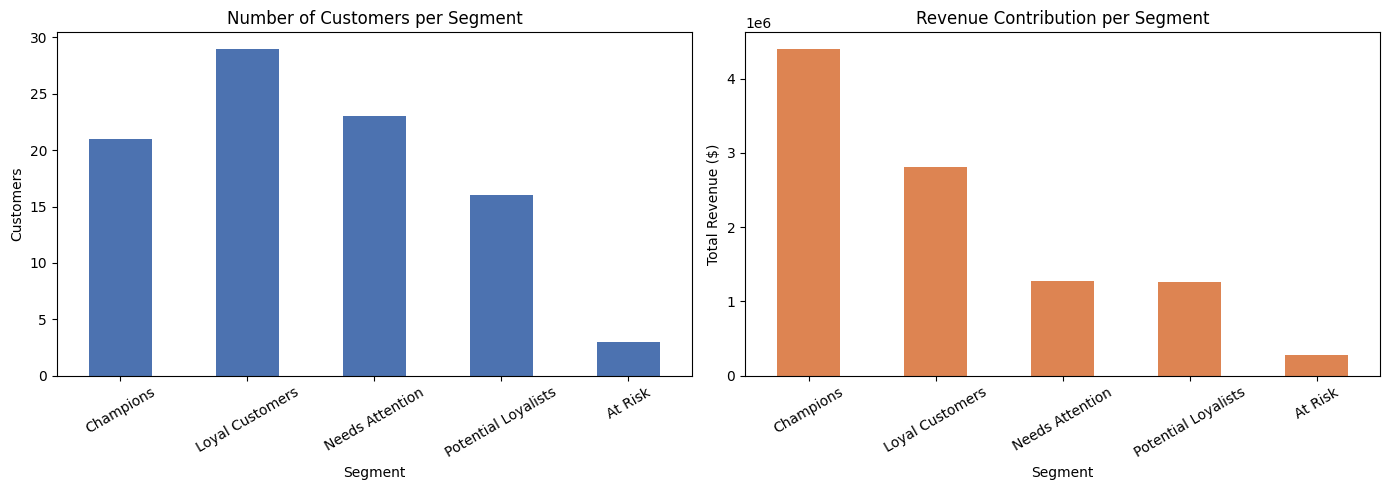

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_summary["Customers"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Number of Customers per Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=30)

segment_summary["Total_Revenue"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Revenue Contribution per Segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../images/rfm_segments.png", dpi=150)
plt.show()

### Business Insight
A small group of **Champions** (customers who order frequently, recently, and in large amounts) generates a disproportionate share of total revenue — the classic 80/20 pattern. The **At Risk** segment is especially important: these are customers who used to spend heavily but haven't ordered recently. Proactively reaching out to this group (e.g., a targeted discount or account-manager check-in) is typically far cheaper than acquiring a new customer of equivalent value.

**Recommended actions by segment:**
- **Champions** → prioritize retention (loyalty perks, early access to new products); protect this relationship above all else.
- **Loyal Customers / Potential Loyalists** → upsell and cross-sell opportunities; nurture toward Champion status.
- **At Risk** → run a win-back campaign before they churn completely.
- **Needs Attention** → lower-touch, cost-efficient marketing (email campaigns rather than dedicated account management).

## 14. Final Business Conclusions

- **Geography:** The USA generated the highest total sales among all countries, followed by Spain and France.
- **Product mix:** Classic Cars was the best-selling product line worldwide, in almost every territory; Trains was the weakest.
- **Seasonality:** Sales consistently peaked during October and November, indicating strong holiday-driven demand.
- **Key accounts:** Euro Shopping Channel was the company's most valuable customer by a wide margin, highlighting the importance of key-account management.
- **Deal structure:** Medium-sized deals generated the largest share of revenue, not large contracts.
- **Fulfillment:** Most revenue came from successfully shipped orders; cancellations/disputes are a small but monitorable share.
- **Pricing:** Revenue is driven more by order quantity than by unit price, and discounting levels vary meaningfully by product line.
- **Customer value:** A small "Champions" segment drives a disproportionate share of revenue, while an identifiable "At Risk" segment represents a concrete win-back opportunity.

**Suggested next steps:** incorporate cost data to analyze true margin (rather than list-price discounting), and track the RFM segments over time to measure whether retention campaigns are moving customers toward "Champion" status.

*A narrative write-up of these findings, aimed at a business audience, is available in [`report/case_study.md`](../report/case_study.md).*
